In [26]:
# General Imports
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Scripts 
folder_path = os.path.abspath("scripts")
sys.path.append(folder_path)

# Derivation of Column Density Maps Routine
from Derive_Density_Maps import derive_density_maps, convert_to_mass

# Visualization Tools
from visualization_tools import show_regions_with_sections, show_Minkowski_Functionals, show_sections_OrionB_vertical, visualize_Mass_Size_D_Diagrams, visualize_Mass_Size_D_Diagramm_as_One

# Minkowski Functionals
from Minkowski_Fractal_Dimension import standard_minkowski_functionals, horizontal_marching_minkowski_functionals, vertical_marching_minkowski_functionals, intercept_corrected_minkowski_functionals 

# Box Counting 
from Box_Counting_Fractal_Dimension import box_counting

# Dendogram-like Tracker
from region_tracker import track_largest_regions, save_regions_to_pickle, load_regions_from_pickle, get_region_from_fractal_dimension_mass_and_size

from skimage.measure import perimeter

# Derive Density Maps
N_H2, N_H2_OA, N_H2_OB, wcs = derive_density_maps(remove_regions=False)

# M_H2_OA = convert_to_mass(N_H2_OA)
# M_H2_OB = convert_to_mass(N_H2_OB)

# Constants for physical conversion
pixel_scale = 0.00417  # degrees per pixel
distance = 412  # parsecs
radians = 180 / np.pi
rad_per_px = pixel_scale / radians
pc_per_px = np.sin(rad_per_px) * distance

In [ ]:
import pickle
import numpy as np

with open("structure_data_OA.pkl", "rb") as f:
    structure_data_OA = pickle.load(f)

with open("structure_data_OB.pkl", "rb") as f:
    structure_data_OB = pickle.load(f)

# Convert your collected data to arrays
region_masses_OA = np.array([s["mass"] for s in structure_data_OA])
region_sizes_OA = np.array([s["size_pc"] for s in structure_data_OA])
region_fractal_dims_OA = np.array([s["fractal_dimension"] for s in structure_data_OA])

mask = region_fractal_dims_OA <= 2.05
region_masses_OA = region_masses_OA[mask]
region_sizes_OA = region_sizes_OA[mask]
region_fractal_dims_OA = region_fractal_dims_OA[mask]

# Remove NaNs for plotting
valid = ~np.isnan(region_masses_OA) & ~np.isnan(region_sizes_OA) & ~np.isnan(region_fractal_dims_OA)
region_masses_OA = region_masses_OA[valid]
region_sizes_OA = region_sizes_OA[valid]
region_fractal_dims_OA = region_fractal_dims_OA[valid]

# OB
region_masses_OB = np.array([s["mass"] for s in structure_data_OB])
region_sizes_OB = np.array([s["size_pc"] for s in structure_data_OB])
region_fractal_dims_OB = np.array([s["fractal_dimension"] for s in structure_data_OB])

mask = region_fractal_dims_OB <= 2.05
region_masses_OB = region_masses_OB[mask]
region_sizes_OB = region_sizes_OB[mask]
region_fractal_dims_OB = region_fractal_dims_OB[mask]

# Remove NaNs for plotting
valid = ~np.isnan(region_masses_OB) & ~np.isnan(region_sizes_OB) & ~np.isnan(region_fractal_dims_OB)
region_masses_OB = region_masses_OB[valid]
region_sizes_OB = region_sizes_OB[valid]
region_fractal_dims_OB = region_fractal_dims_OB[valid]

In [27]:
import os
import pandas as pd

curr_folder = os.getcwd()

# Path to your .dat file
table_file_path = os.path.join(curr_folder, "Megeath", "table4.dat.txt")

# Define the column names (based on the provided table headers, modifying the RA and DE columns)
column_names = ['Seq', 'RA_DEC', 'Jmag', 'e_Jmag', 'Hmag', 'e_Hmag',
                'Kmag', 'e_Kmag', '[3.6]', 'e_[3.6]', '[4.5]', 'e_[4.5]', '[5.8]', 'e_[5.8]',
                '[8.0]', 'e_[8.0]', '[24]', 'e_[24]', 'AKs', 'alpha', 'Cl']

# Read the file, skipping the first few lines, assuming fixed-width formatting
data = pd.read_fwf(table_file_path, skiprows=5, names=column_names, delimiter="|")

# Now split the 'RA_DEC' column into individual RA and DEC components based on spaces
# Assuming the format: "RAh RAm RAs DEd DEm DEs"
ra_dec_split = data['RA_DEC'].str.split(expand=True)

# Add the RA and DEC columns back to the DataFrame
data['RAh'] = 5
data['RAm'] = ra_dec_split[1]
data['RAs'] = ra_dec_split[2]
data['DEd'] = ra_dec_split[3]
data['DEm'] = ra_dec_split[4]
data['DEs'] = ra_dec_split[5]

# Drop the original combined column
data.drop(columns=['RA_DEC'], inplace=True)

# Display the first few rows to confirm
print(data.iloc[1]['RAh'])

5


In [28]:
import os
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u

# ALL YSOs in the area
# Path to your .dat file
table_file_path = os.path.join(curr_folder, "Megeath", "table4.dat.txt")

# Define the column names (based on the provided table headers, modifying the RA and DE columns)
column_names = ['Seq', 'RA_DEC', 'Jmag', 'e_Jmag', 'Hmag', 'e_Hmag',
                'Kmag', 'e_Kmag', '[3.6]', 'e_[3.6]', '[4.5]', 'e_[4.5]', '[5.8]', 'e_[5.8]',
                '[8.0]', 'e_[8.0]', '[24]', 'e_[24]', 'AKs', 'alpha', 'Cl']

# Read the file, skipping the first few lines, assuming fixed-width formatting
data = pd.read_fwf(table_file_path, skiprows=5, names=column_names, delimiter="|")

# Now split the 'RA_DEC' column into individual RA and DEC components based on spaces
ra_dec_split = data['RA_DEC'].str.split(expand=True)

# Add the RA and DEC columns back to the DataFrame as integers/floats
data['RAh'] = 5
data['RAm'] = ra_dec_split[1].astype(float)
data['RAs'] = ra_dec_split[2].astype(float)
data['DEd'] = ra_dec_split[3].astype(float)
data['DEm'] = ra_dec_split[4].astype(float)
data['DEs'] = ra_dec_split[5].astype(float)

# Drop the original combined column
data.drop(columns=['RA_DEC'], inplace=True)

# Convert RA/DEC to decimal degrees
data['RA_deg'] = 15 * (data['RAh'] + data['RAm'] / 60 + data['RAs'] / 3600)
data['DEC_deg'] = data['DEd'] + np.sign(data['DEd'])*data['DEm'] / 60 + np.sign(data['DEd'])*data['DEs'] / 3600

# Handle negative declination degrees correctly
# data['DEC_deg'] = data.apply(lambda row: -row['DEC_deg'] if row['DEd'] < 0 else row['DEC_deg'], axis=1)

# Create SkyCoord object and transform to galactic coordinates
coords = SkyCoord(ra=data['RA_deg']*u.degree, dec=data['DEC_deg']*u.degree, frame='icrs', unit=u.degree)
data['l'] = coords.galactic.l.degree
data['b'] = coords.galactic.b.degree
# Orion A and Orion B
l_min_A, l_max_A = 206, 217
b_min_A, b_max_A = -21, -17

filtered_data_OA = data[(data['l'] >= 206) & (data['l'] <= 217) & (data['b'] >= -21) & (data['b'] <= -17)]

l_min_B, l_max_B = 203, 210
b_min_B, b_max_B = -17, -12

# Filter for objects within the specified galactic coordinates
filtered_data_OB = data[(data['l'] >= 203) & (data['l'] <= 210) & (data['b'] >= -17) & (data['b'] <= -12)]

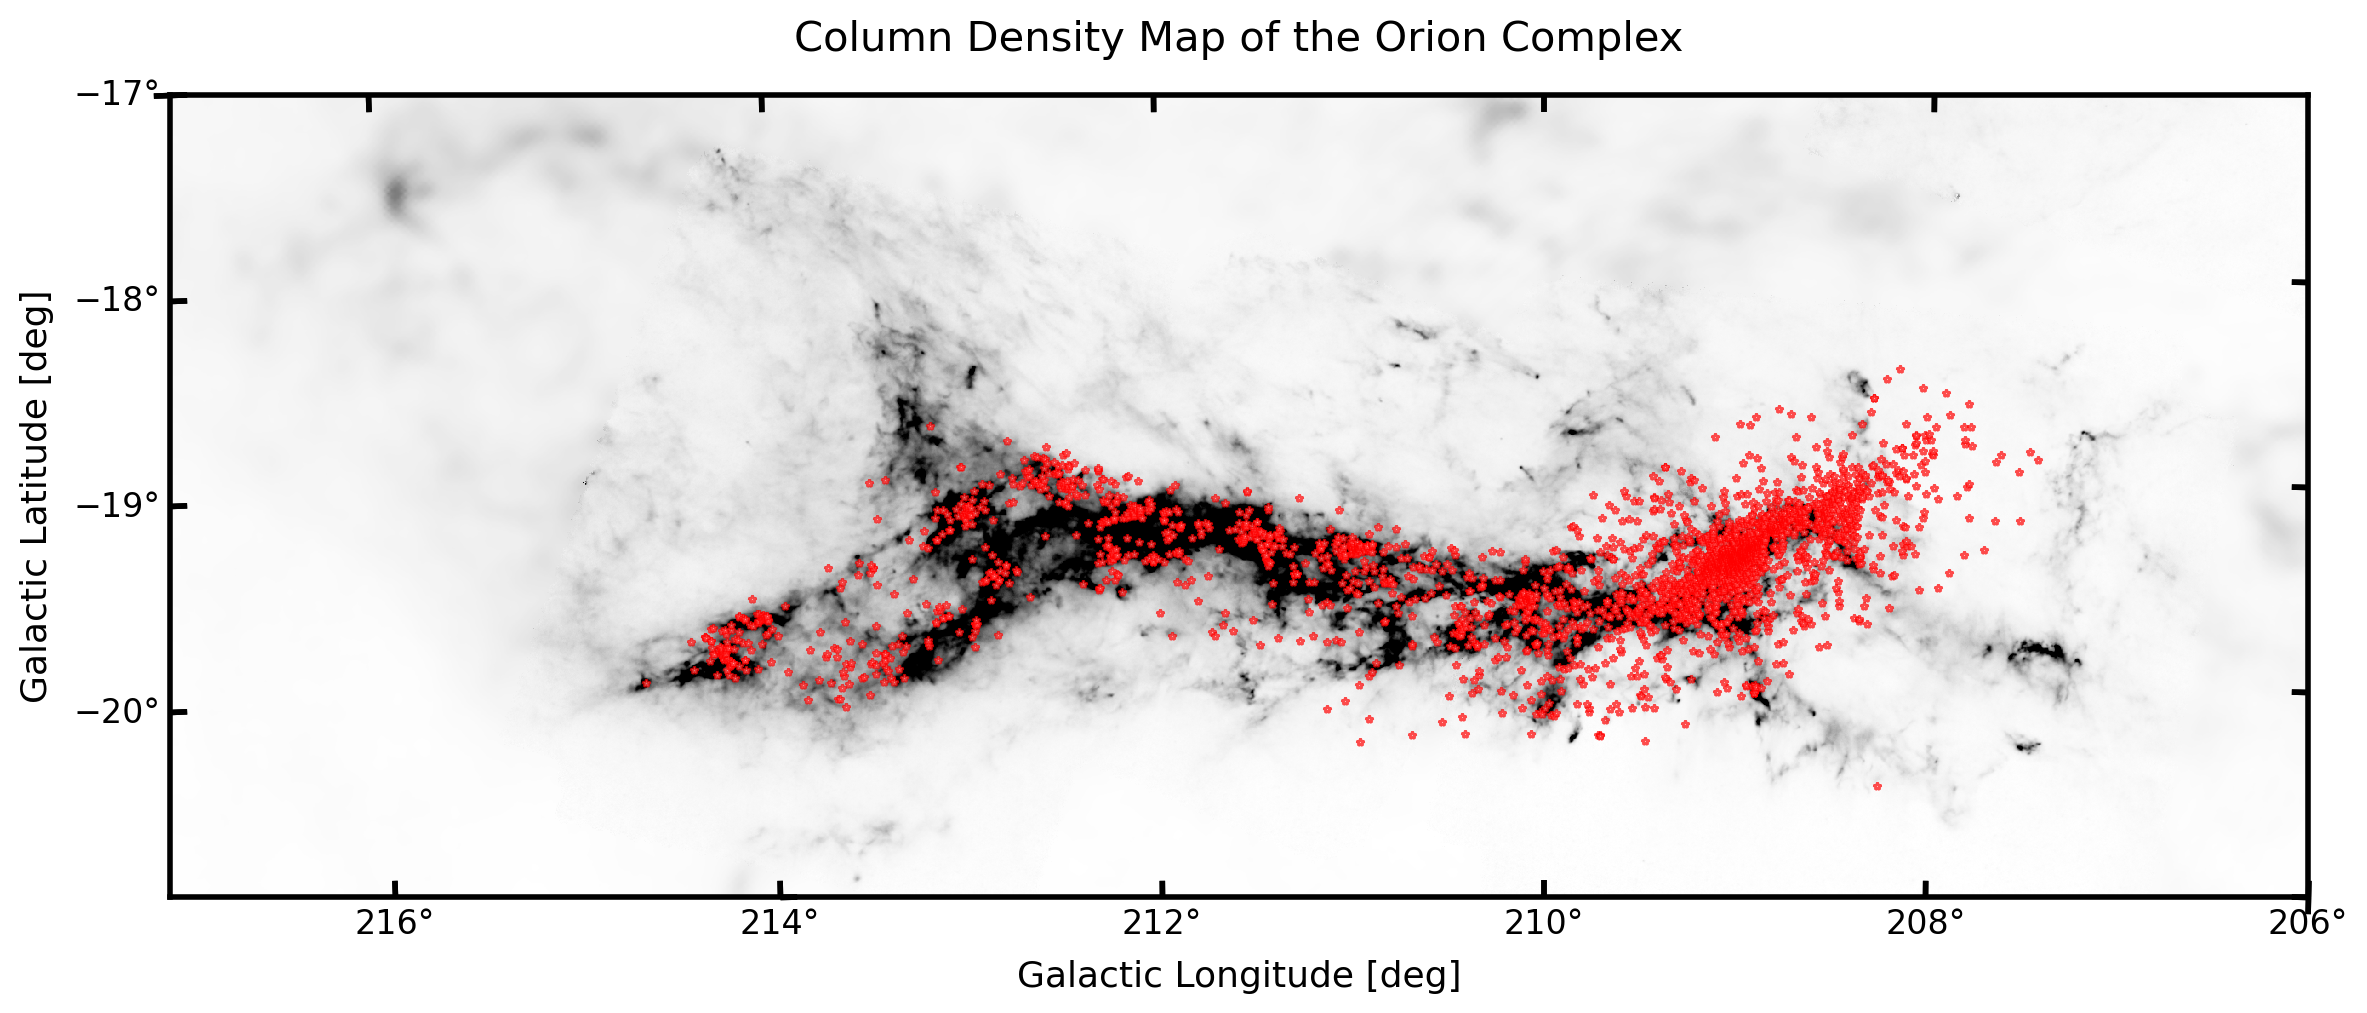

In [29]:
from astropy.coordinates import SkyCoord
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import ScalarFormatter
import astropy.units as u
import matplotlib.patches as patches

yso_coords = SkyCoord(
    filtered_data_OA['l'].values, 
    filtered_data_OA['b'].values, 
    frame='galactic', 
    unit=u.deg
)

yso_pixel_coords = [wcs[0].world_to_pixel(coord) for coord in yso_coords]

l_min_A, l_max_A = 206, 217
b_min_A, b_max_A = -21, -17

min_coord_A = SkyCoord(l_min_A, b_min_A, frame='galactic', unit=u.deg)
max_coord_A = SkyCoord(l_max_A, b_max_A, frame='galactic', unit=u.deg)

min_pixel_A = wcs[:][:][0].world_to_pixel(min_coord_A)
max_pixel_A = wcs[:][:][0].world_to_pixel(max_coord_A)

l_min_B, l_max_B = 203, 210
b_min_B, b_max_B = -17, -12

min_coord_B = SkyCoord(l_min_B, b_min_B, frame='galactic', unit=u.deg)
max_coord_B = SkyCoord(l_max_B, b_max_B, frame='galactic', unit=u.deg)

min_pixel_B = wcs[:][:][0].world_to_pixel(min_coord_B)
max_pixel_B = wcs[:][:][0].world_to_pixel(max_coord_B)

min_value = np.percentile(N_H2, 1)  # 2nd percentile
max_value = np.percentile(N_H2, 99)  # 98th percentile

plt.figure(figsize=(12, 10))
ax = plt.subplot(111, projection=wcs[0])

# Plot the map
sp = ax.imshow(N_H2, vmin=min_value, vmax=max_value, interpolation=None, origin='lower', cmap='Greys')
ax.set_title("Column Density Map of the Orion Complex", fontsize=15, pad=16)
ax.set_xlabel("Galactic Longitude [deg]", fontsize=13)
ax.set_ylabel("Galactic Latitude [deg]", fontsize=13)

# Create colorbar
# fig = plt.gcf()  # Get the current figure
# cbar = fig.colorbar(sp)  # Label the colorbar
# cbar.ax.tick_params(labelsize=12)
# cbar.set_label('Column Density', fontsize=13)

for i, pixel_coord in enumerate(yso_pixel_coords):
    if i == 0:  # Add label only for the first YSO
        ax.plot(pixel_coord[0], pixel_coord[1], '*', color='red', markersize=3, alpha=0.7, label='YSO')
    else:
        ax.plot(pixel_coord[0], pixel_coord[1], '*', color='red', markersize=3, alpha=0.7)  # No label for subsequent points
        
ax.set(xlim=[max_pixel_A[0], min_pixel_A[0]], ylim=[min_pixel_A[1], max_pixel_A[1]])

plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_8604\791515838.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right')


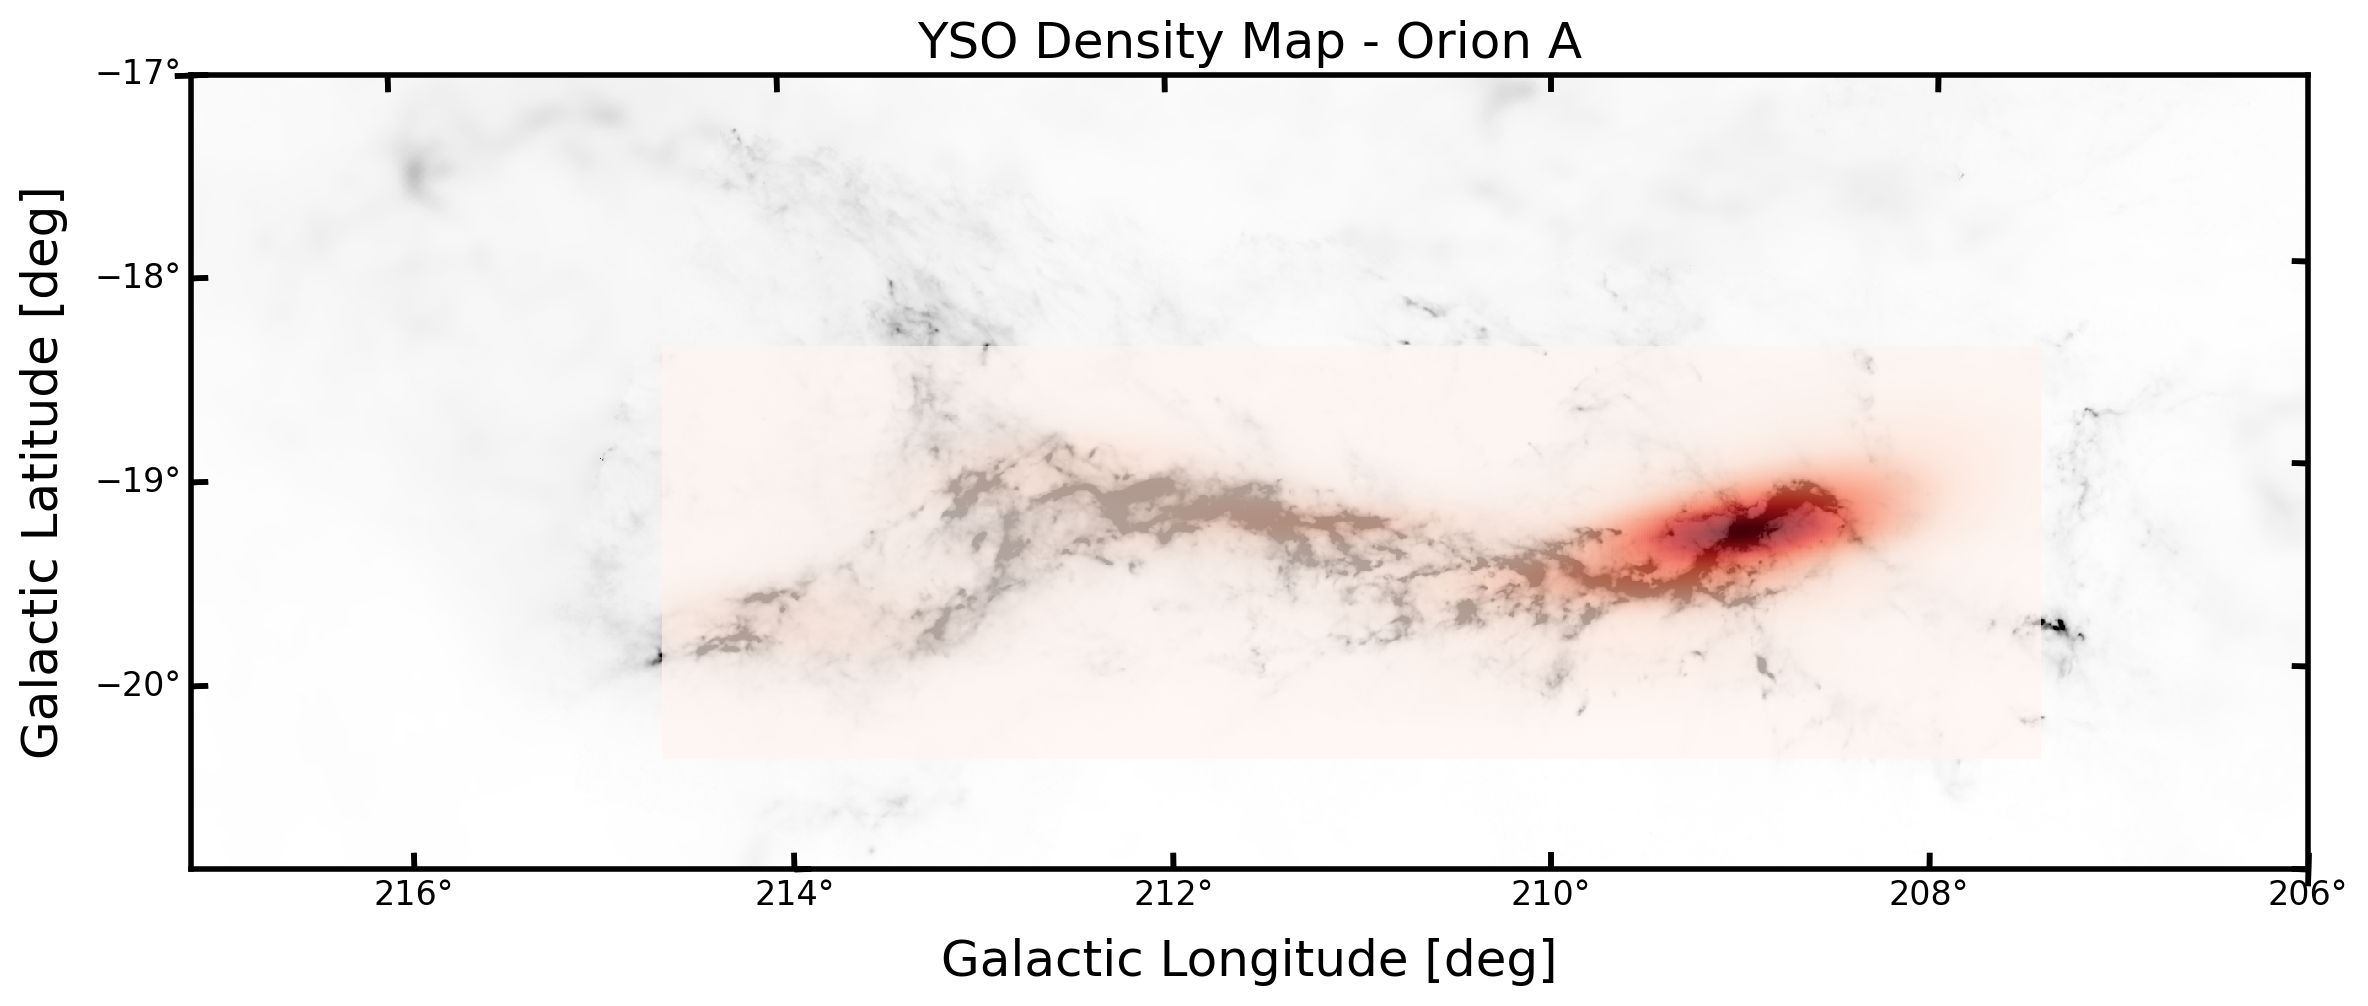

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
from scipy.stats import gaussian_kde

# Convert Galactic coordinates to SkyCoord
yso_coords = SkyCoord(
    filtered_data_OA['l'].values, 
    filtered_data_OA['b'].values, 
    frame='galactic', 
    unit=u.deg
)

# Convert YSO world coords to pixel coords
yso_pixel_coords = np.array([wcs[0].world_to_pixel(coord) for coord in yso_coords])
x_pix = yso_pixel_coords[:, 0]
y_pix = yso_pixel_coords[:, 1]

# image_shape = N_H2_OA.shape
# x_pix = image_shape[1]
# y_pix = image_shape[0]

# Compute 2D KDE for YSO density
xy = np.vstack([x_pix, y_pix])
kde = gaussian_kde(xy)
xgrid = np.linspace(min(x_pix), max(x_pix), N := 500)
ygrid = np.linspace(min(y_pix), max(y_pix), N)
X, Y = np.meshgrid(xgrid, ygrid)
positions = np.vstack([X.ravel(), Y.ravel()])
Z = kde(positions).reshape(X.shape)

# Plot background H₂ mass map
min_value = np.percentile(N_H2_OA, 1)
max_value = np.percentile(N_H2_OA, 99)

# Plot
plt.figure(figsize=(12, 10))
ax = plt.subplot(111, projection=wcs[0])

# Plot the map
sp = ax.imshow(N_H2, vmin=min_value, vmax=max_value, interpolation=None, origin='lower', cmap='Greys')
ax.set_title("Column Density Map of the Orion Complex", fontsize=15, pad=16)
ax.set_xlabel("Galactic Longitude [deg]", fontsize=13)
ax.set_ylabel("Galactic Latitude [deg]", fontsize=13)

# Overlay KDE density map of YSOs
ax.imshow(Z, extent=[xgrid.min(), xgrid.max(), ygrid.min(), ygrid.max()],
          origin='lower', cmap='Reds', alpha=0.7)

# Labels and limits
ax.set_title("YSO Density Map - Orion A", fontsize=18)
ax.set_xlabel("Galactic Longitude [deg]", fontsize=18)
ax.set_ylabel("Galactic Latitude [deg]", fontsize=18)
ax.set(xlim=[max_pixel_A[0], min_pixel_A[0]], ylim=[min_pixel_A[1], max_pixel_A[1]])

# Optional: add original YSO points
# ax.plot(x_pix, y_pix, 'r*', markersize=2, label='YSOs')

# Add legend if needed
ax.legend(loc='upper right')
plt.show()

## **Orion B**

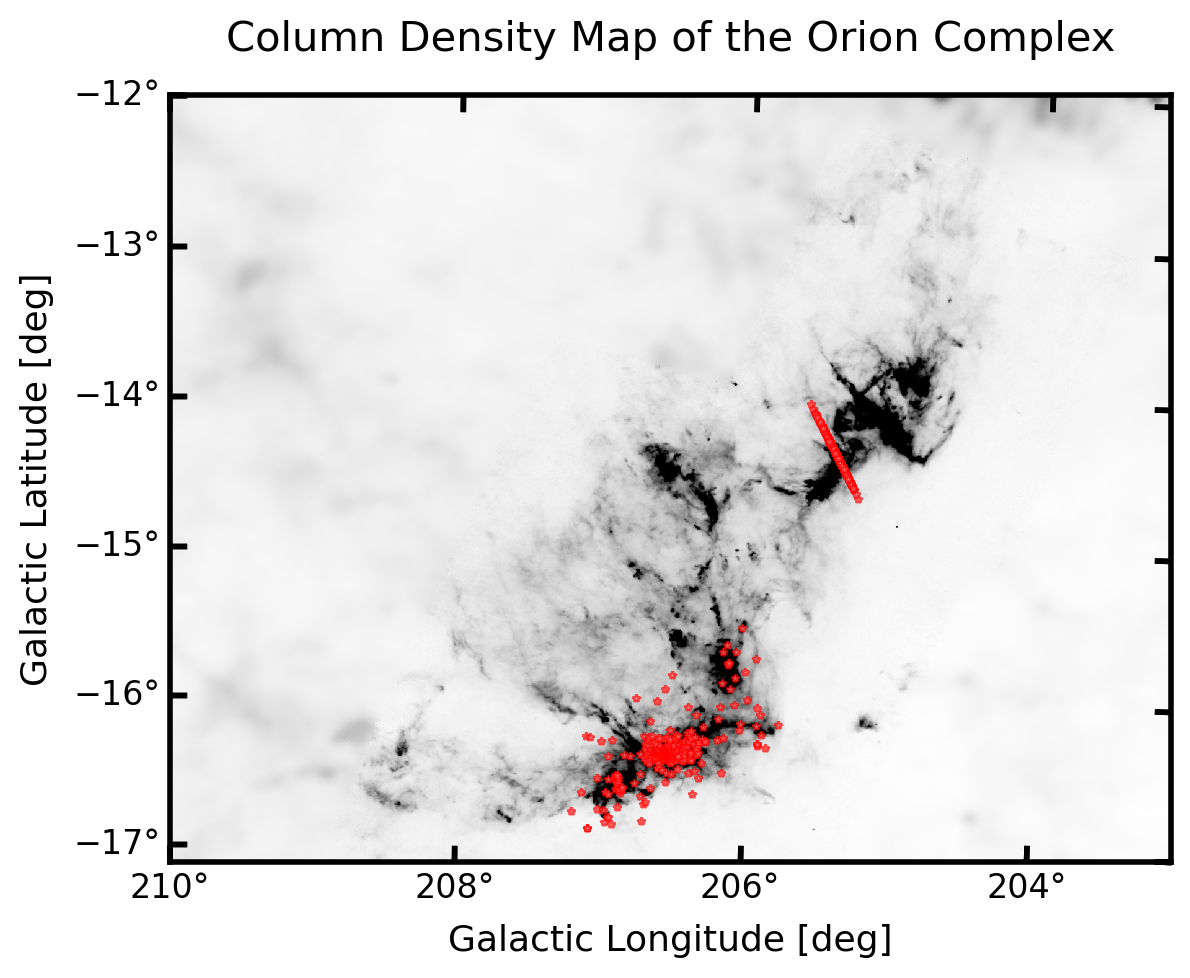

In [23]:
from astropy.coordinates import SkyCoord
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import ScalarFormatter
import astropy.units as u
import matplotlib.patches as patches

yso_coords = SkyCoord(
    filtered_data_OB['l'].values, 
    filtered_data_OB['b'].values, 
    frame='galactic', 
    unit=u.deg
)

yso_pixel_coords = [wcs[0].world_to_pixel(coord) for coord in yso_coords]

l_min_B, l_max_B = 203, 210
b_min_B, b_max_B = -17, -12

min_coord_B = SkyCoord(l_min_B, b_min_B, frame='galactic', unit=u.deg)
max_coord_B = SkyCoord(l_max_B, b_max_B, frame='galactic', unit=u.deg)

min_pixel_B = wcs[:][:][0].world_to_pixel(min_coord_B)
max_pixel_B = wcs[:][:][0].world_to_pixel(max_coord_B)

min_value = np.percentile(N_H2, 1)  # 2nd percentile
max_value = np.percentile(N_H2, 99)  # 98th percentile

plt.figure(figsize=(32, 30))
ax = plt.subplot(111, projection=wcs[0])

# Plot the map
sp = ax.imshow(N_H2, vmin=min_value, vmax=max_value, interpolation=None, origin='lower', cmap='Greys')
ax.set_title("Column Density Map of the Orion Complex", fontsize=15, pad=16)
ax.set_xlabel("Galactic Longitude [deg]", fontsize=13)
ax.set_ylabel("Galactic Latitude [deg]", fontsize=13)

for i, pixel_coord in enumerate(yso_pixel_coords):
    if i == 0:  # Add label only for the first YSO
        ax.plot(pixel_coord[0], pixel_coord[1], '*', color='red', markersize=3, alpha=0.7, label='YSO')
    else:
        ax.plot(pixel_coord[0], pixel_coord[1], '*', color='red', markersize=3, alpha=0.7)  # No label for subsequent points
        
# ax.set(xlim=[max_pixel_A[0], min_pixel_A[0]], ylim=[min_pixel_A[1], max_pixel_A[1]])
ax.set(xlim=[max_pixel_B[0], min_pixel_B[0]], ylim=[min_pixel_B[1], max_pixel_B[1]])

plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_8604\2409991371.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right')


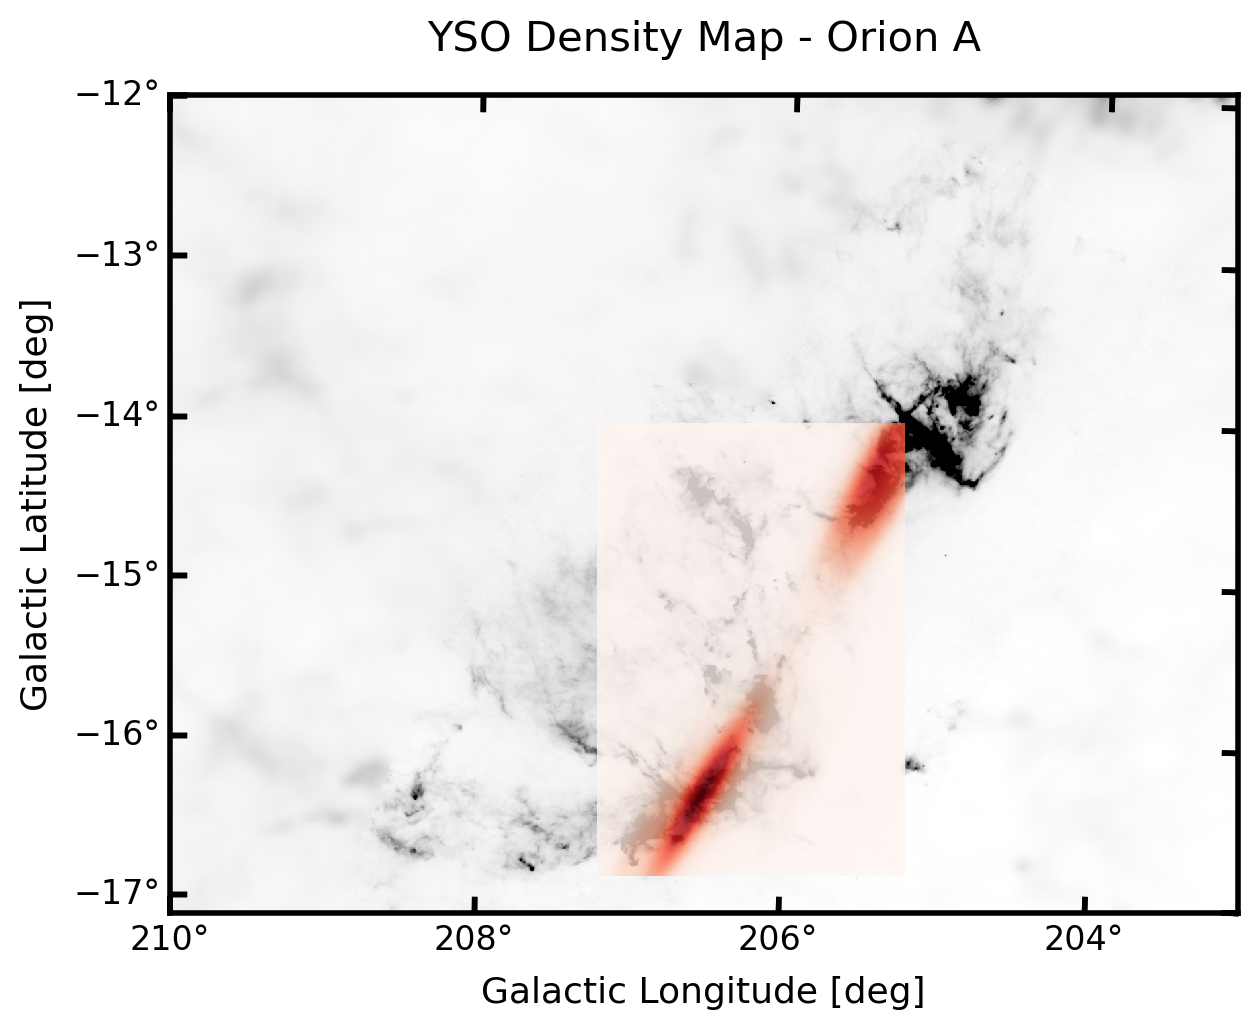

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
from scipy.stats import gaussian_kde

# Convert Galactic coordinates to SkyCoord
yso_coords = SkyCoord(
    filtered_data_OB['l'].values, 
    filtered_data_OB['b'].values, 
    frame='galactic', 
    unit=u.deg
)

l_min_B, l_max_B = 203, 210
b_min_B, b_max_B = -17, -12

min_coord_B = SkyCoord(l_min_B, b_min_B, frame='galactic', unit=u.deg)
max_coord_B = SkyCoord(l_max_B, b_max_B, frame='galactic', unit=u.deg)

min_pixel_B = wcs[:][:][0].world_to_pixel(min_coord_B)
max_pixel_B = wcs[:][:][0].world_to_pixel(max_coord_B)

# Convert YSO world coords to pixel coords
yso_pixel_coords = np.array([wcs[0].world_to_pixel(coord) for coord in yso_coords])
x_pix = yso_pixel_coords[:, 0]
y_pix = yso_pixel_coords[:, 1]

# Compute 2D KDE for YSO density
xy = np.vstack([x_pix, y_pix])
kde = gaussian_kde(xy)
xgrid = np.linspace(min(x_pix), max(x_pix), N := 500)
ygrid = np.linspace(min(y_pix), max(y_pix), N)
X, Y = np.meshgrid(xgrid, ygrid)
positions = np.vstack([X.ravel(), Y.ravel()])
Z = kde(positions).reshape(X.shape)

# Plot background H₂ mass map
min_value = np.percentile(N_H2_OB, 1)
max_value = np.percentile(N_H2_OB, 99)

# Plot
plt.figure(figsize=(34, 30))
ax = plt.subplot(111, projection=wcs[0])

# Plot the map
sp = ax.imshow(N_H2, vmin=min_value, vmax=max_value, interpolation=None, origin='lower', cmap='Greys')
ax.set_title("Column Density Map of the Orion Complex", fontsize=15, pad=16)
ax.set_xlabel("Galactic Longitude [deg]", fontsize=13)
ax.set_ylabel("Galactic Latitude [deg]", fontsize=13)

# Overlay KDE density map of YSOs
ax.imshow(Z, extent=[xgrid.min(), xgrid.max(), ygrid.min(), ygrid.max()],
          origin='lower', cmap='Reds', alpha=0.8)

# Labels and limits
ax.set_title("YSO Density Map - Orion A", fontsize=15, pad=16)
ax.set_xlabel("Galactic Longitude [deg]", fontsize=13)
ax.set_ylabel("Galactic Latitude [deg]", fontsize=13)
ax.set(xlim=[max_pixel_B[0], min_pixel_B[0]], ylim=[min_pixel_B[1], max_pixel_B[1]])

# Optional: add original YSO points
# ax.plot(x_pix, y_pix, 'r*', markersize=2, label='YSOs')

# Add legend if needed
ax.legend(loc='upper right')
plt.show()